In [1]:
from few.trajectory.ode import KerrEccEqFlux_nex, KerrEccEqFlux
import matplotlib.pyplot as plt
import numpy as np
from few.utils.mappings.kerrecceq import (DELTAPMIN_REGIONC, DELTAPMAX,kerrecceq_backward_map_nex, kerrecceq_forward_map_nex)
from few.trajectory.inspiral import EMRIInspiral
from few.utils.geodesic import get_separatrix, get_fundamental_frequencies
import tqdm as tq

def shrink_match(p1,p2):
    len1 =  len(p1)
    len2 = len(p2)
    

    min_len = min([len1,len2])
    print(min_len)

    return p1[:min_len], p2[:min_len], min_len


In [2]:
insp_nex = EMRIInspiral(func=KerrEccEqFlux_nex)
insp = EMRIInspiral(func=KerrEccEqFlux)
rhs_nex = KerrEccEqFlux_nex()
rhs_nex_ELQ =KerrEccEqFlux_nex(flux_output_convention="ELQ")

### Compare few and nex model trajectories

931


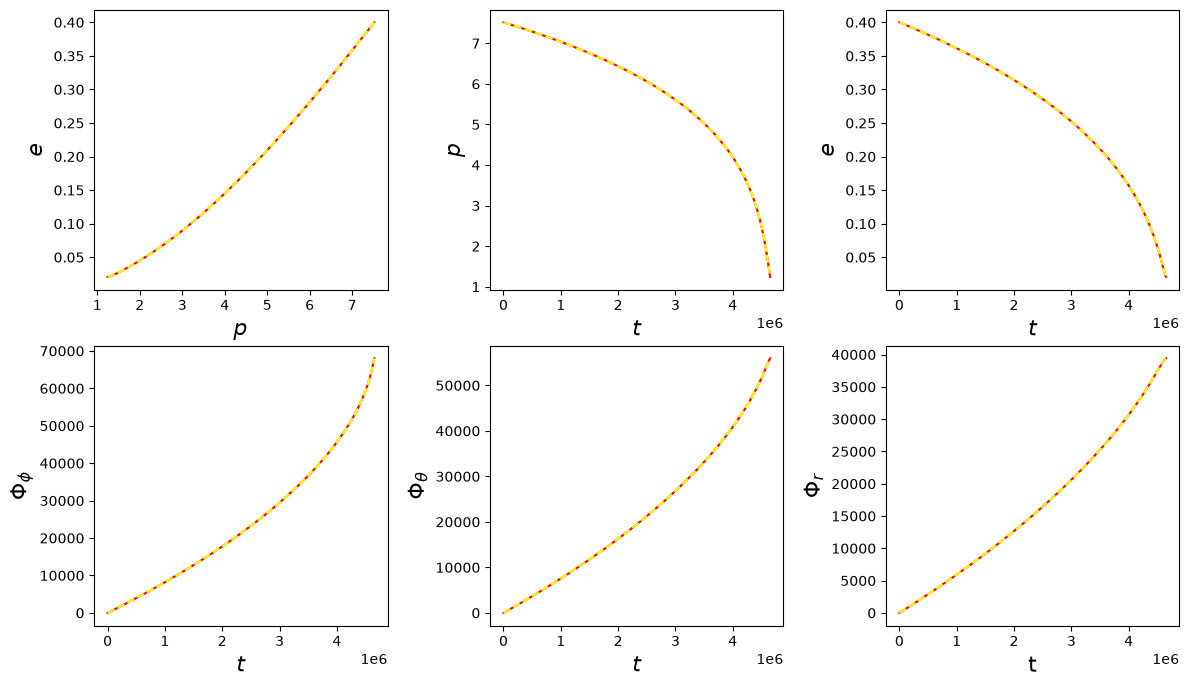

In [5]:
m1 = 1e6
m2 = 1e2
a = 0.999
e0 = 0.4
xI0 = 1.0  

pLSO = get_separatrix(a,e0,xI0)
p0=pLSO+6

T = 100  #
new_t = np.linspace(0,5e7,10000)

traj_pars = [m1, m2, a, p0, e0, xI0]

t, p, e, xI, Phi_phi, Phi_theta, Phi_r = insp(*traj_pars, T=T, new_t = new_t,upsample=True,fix_t=True)
t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars, T=T, new_t =new_t, upsample = True, fix_t=True)
print(len(p2))

Omega_phi, Omega_theta, Omega_r = get_fundamental_frequencies(a,p,e,xI)

fig, axes = plt.subplots(2, 3)
plt.subplots_adjust(wspace=0.35)
fig.set_size_inches(14, 8)
axes = axes.ravel()

ylabels = [ r"$e$", r"$p$", r"$e$", r"$\Phi_\phi$",r"$\Phi_\theta$", r"$\Phi_r$"]
xlabels = [ r"$p$", r"$t$", r"$t$", r"$t$", r"$t$","t"]
ys = [e, p, e, Phi_phi, Phi_theta, Phi_r]
xs = [p, t, t, t, t, t]

y2s = [e2, p2, e2, Phi_phi2, Phi_theta2, Phi_r2]
x2s = [p2, t2, t2, t2, t2, t2]

for i, (ax, x, y, xlab, ylab,x2,y2) in enumerate(zip(axes, xs, ys, xlabels, ylabels,x2s,y2s)):
    ax.plot(x, y,color="red")
    ax.plot(x2, y2,"--",color = "yellow")
    ax.set_xlabel(xlab, fontsize=16)
    ax.set_ylabel(ylab, fontsize=16)

Text(0.5, 0.98, 'Relative difference between NEX and FEW of p and e for an inspiral with a=0.999')

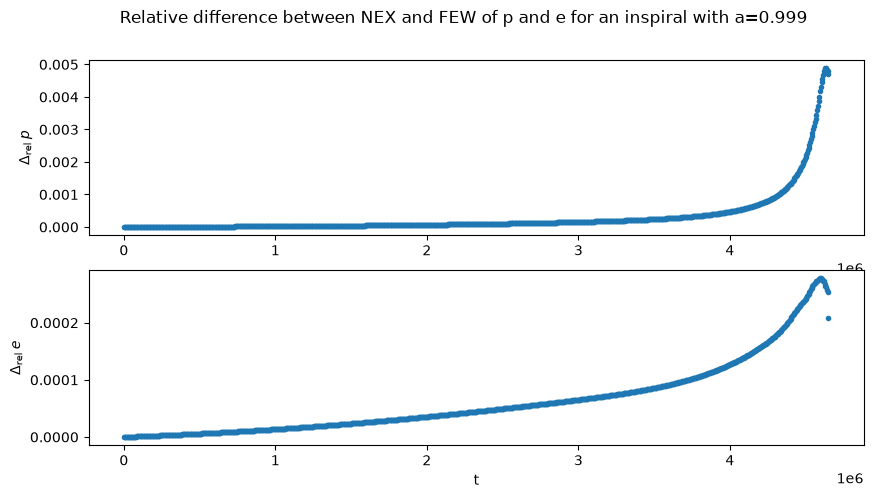

In [6]:
fig, axs = plt.subplots(2,1,figsize = (10,5))


axs[0].plot(t,np.abs((p-p2)/p),".")
axs[1].plot(t,np.abs((e-e2)),".")  # remove singularity if circular

axs[0].set_ylabel(r"$\Delta_{\text{rel }} p$")
axs[1].set_ylabel(r"$\Delta_{\text{rel }} e$")
axs[1].set_xlabel("t")
plt.suptitle(rf"Relative difference between NEX and FEW of p and e for an inspiral with a={a}")

1.0015896068752117 1.0490170809884298
1.075181936824412 1.0566843142912292
1.1501423879696715 1.066067198748664
1.2251278246291142 1.076404482688992
1.3001210226820088 1.08775584211236


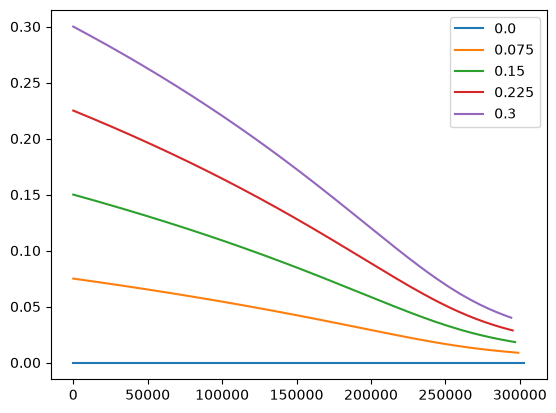

In [7]:
e_vals =np.linspace(0.0,0.3,5)
for e_val in e_vals:
    m1 = 1e6
    m2 = 1e2
    a = 1-10**(-9)
    e0 = e_val
    xI0 = 1.0  
    
    pLSO = get_separatrix(a,e0,xI0)
    p0=3
    
    T = 5  #
    
    traj_pars = [m1, m2, a, p0, e0, xI0]
    
    t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars, T=T)


    plt.plot(t2,e2,label = f"{round(e_val,3)}")



    print(pLSO,p2[-1])

plt.legend()
#plt.xlim(0,1e5)

## Calculate $\partial_{a}r$

In [8]:
insp_nex = EMRIInspiral(func=KerrEccEqFlux_nex)
                 

In [9]:
def diff_a(a,da,e_val):
    a = a 
    da = da
    e0 = e_val
    if a+da >=1-10**(-12):
        raise ValueError("a + da out of bounds")
    
    m1 = 1e6
    m2 = 1e2
    xI0 = 1.0  
    
    pLSO = get_separatrix(a,e0,xI0)
    p0=10
    t_max = 3.7e7
    t_new = np.linspace(0,t_max,1000)
    
    T = 10
    
    traj_pars1 = [m1, m2, a+da, p0, e0, xI0]
    traj_pars2 = [m1, m2, a-da, p0, e0, xI0]

    traj_1 = t1, p1, e1, xI1, Phi_phi1, Phi_theta1, Phi_r1 = insp_nex(*traj_pars1, T=T, new_t = t_new, fix_t=True, upsample = True)
    traj_2 = t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars2, T=T, new_t = t_new, fix_t=True, upsample = True)
    print(len(p1), len(p2))
 
    #Ensure that the arrays are the same length, over the same interval of time
 #   t_max = max(t1[-1],t2[-1])
   # t_new = np.linspace(0,t_max,100000)
  #  p1_new = np.interp(t_new,t1,p1)
   # p2_new = np.interp(t_new,t2,p2)


    return t1,p1,p2,e1,e2, (p1 - p2)/(2*da)
    
    

In [10]:
n=7
a= 1-10**(-n)
da= 10**(-n-4)
e_vals = [0.000001,0.4]

diffs = []
for e in tq.tqdm(e_vals):
    dela = diff_a(a,da,e)
    diffs.append(dela)


 50%|██████████████████████                      | 1/2 [00:00<00:00,  4.90it/s]

343 343


100%|████████████████████████████████████████████| 2/2 [00:00<00:00,  4.54it/s]

358 358


/tmp/ipykernel_11598/3187673900.py:16: RuntimeWarning: divide by zero encountered in log10
  ax_main.plot(t*sec_to_day,2*np.log10(np.abs(dr)),label = f"e={e}")


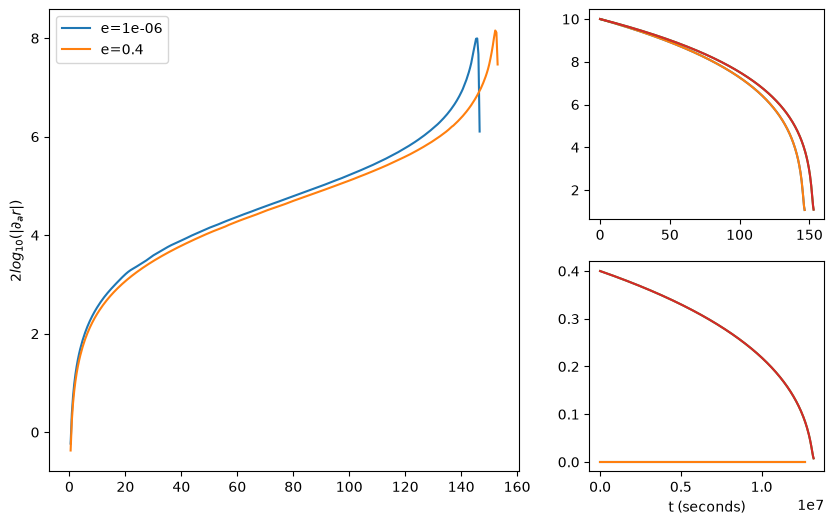

In [11]:
sec_to_day = 1/(60*60*24)

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1])

# Large plot on the left
ax_main = fig.add_subplot(gs[:, 0])

# Two smaller plots on the right
ax_top = fig.add_subplot(gs[0, 1])
ax_bottom = fig.add_subplot(gs[1, 1])

for e,del_a in zip(e_vals, diffs):
    t, p1, p2 ,e1, e2,  dr = del_a

    ax_main.plot(t*sec_to_day,2*np.log10(np.abs(dr)),label = f"e={e}")
    ax_top.plot(t*sec_to_day,p1,label = f"e={e}")
    ax_top.plot(t*sec_to_day,p2,label = f"e={e}")

    ax_bottom.plot(t,e1,label = f"e={e}")
    ax_bottom.plot(t,e2,label = f"e={e}")
    


plt.xlabel("t (seconds)")
ax_main.set_ylabel(r"$2log_{10}(|\partial_{a}r|)$")
ax_main.legend()

In [12]:
1/60*60*24

24.0

# Look at circular orbits

In [13]:
rhs_nex = KerrEccEqFlux_nex()
insp_nex = EMRIInspiral(func=KerrEccEqFlux_nex)

In [14]:
n=10
a = 1-10**(-n)
e0 = 0.00

m1 = 1e6
m2 = 1e2
xI0 = 1.0  
rhs_nex.add_fixed_parameters(m1, m2, a)

pLSO = get_separatrix(a,e0,xI0)
p0=3
t_max = 2e10
t_new = np.linspace(0,t_max,100000)

T = 4  


traj_pars1 = [m1, m2, a, p0, e0, xI0]

traj_1 = t1, p1, e1, xI1, Phi_phi1, Phi_theta1, Phi_r1 = insp_nex(*traj_pars1, T=T ) #,new_t = t_new, fix_t=True, upsample = True)
pdots = []
edots = []
for p,e in zip(p1,e1):
    pdots.append(rhs_nex([p, e, 1])[0])
    edots.append(rhs_nex([p, e, 1])[1])


1.0481647554854716


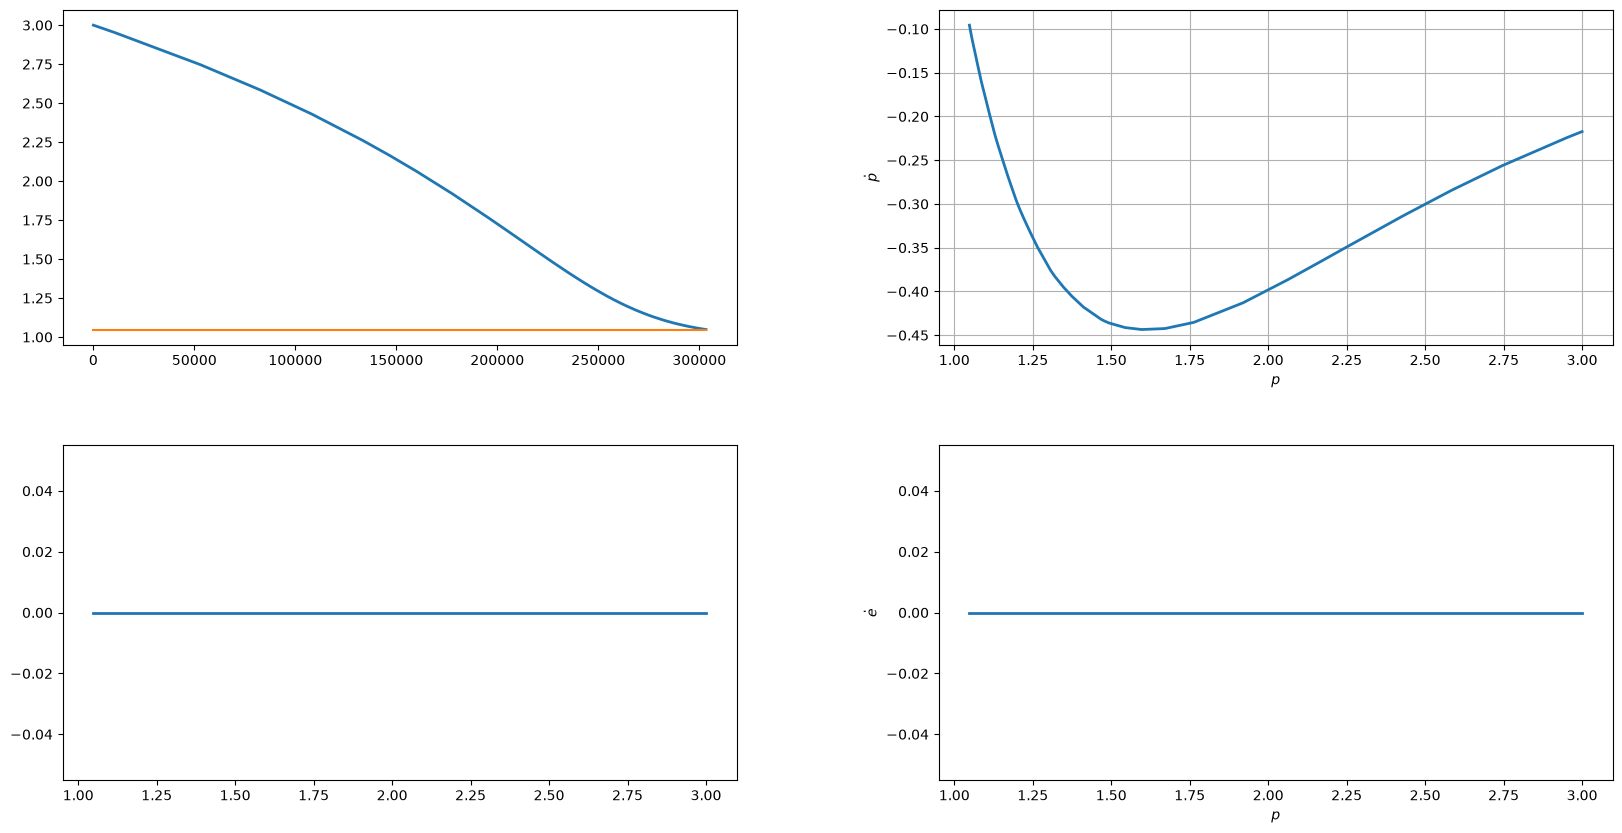

In [15]:
fig,axs = plt.subplots(2,2,figsize = (20,10))
lws=2

axs[0,0].plot(t1,p1,label = f"n= {round(n,3)}",lw=lws)
axs[0,1].plot(p1,pdots,lw=lws)
axs[1,0].plot(p1,e1 ,label = f"n={round(n,3)}",lw=lws)
axs[1,1].plot(p1,edots, label = f"{round(n,3)}",lw=lws)

axs[0,1].set_ylabel(r"$\dot{p}$")
axs[1,1].set_ylabel(r"$\dot{e}$")
axs[0,1].set_xlabel(r"$p$")
axs[1,1].set_xlabel(r"$p$")
plt.subplots_adjust(hspace=0.3)
plt.subplots_adjust(wspace=0.3)
axs[0,1].grid()

#axs[0,1].set_ylim(-0.001,0.0001)


final_psep = get_separatrix(a,e1[-1],xI0)
axs[0,0].plot(t1 , np.ones_like(t1)*final_psep + 2* DELTAPMIN_REGIONC )


tmax = t1[-1]
#axs[0,0].set_xlim(0,tmax)
print(p1[-1])


In [16]:
p1[-1], get_separatrix(a,0,1)+2*DELTAPMIN_REGIONC , rhs_nex([p1[-1], 0, 1])[0]

(np.float64(1.0481647554854716),
 1.0481647554854594,
 np.float64(-0.09563165324312636))

In [17]:
def drE(r,a):
    num = r**2 - 3*a**2 + 8*a *np.sqrt(r) - 6*r
    den = 2*r**(7/4) * (r**(3/2)-3*np.sqrt(r)+2*a)**(3/2)
    return num/den

In [18]:
drE(1,0.99)

/tmp/ipykernel_11598/1876612781.py:3: RuntimeWarning: invalid value encountered in scalar power
  den = 2*r**(7/4) * (r**(3/2)-3*np.sqrt(r)+2*a)**(3/2)


np.float64(nan)

/tmp/ipykernel_11598/1876612781.py:3: RuntimeWarning: invalid value encountered in power
  den = 2*r**(7/4) * (r**(3/2)-3*np.sqrt(r)+2*a)**(3/2)


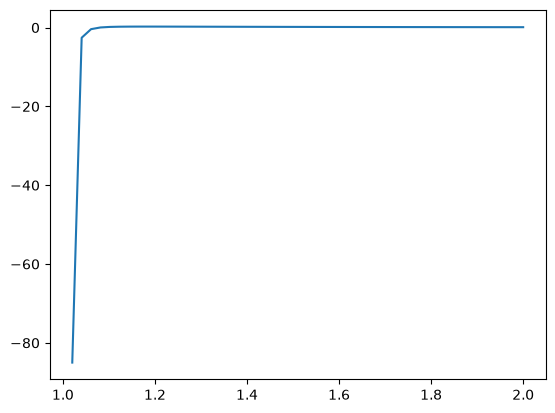

In [19]:
r_vals = np.linspace(1,2)
plt.plot(r_vals,drE(r_vals,0.9999))

In [10]:
insp_nex =  EMRIInspiral(func=KerrEccEqFlux_nex,integrate_constants_of_motion=False)

Text(0.5, 0.98, '$(p_0, e_0, a) = \\left(2.5, 0.1, 1-10^{-n}\\right)$')

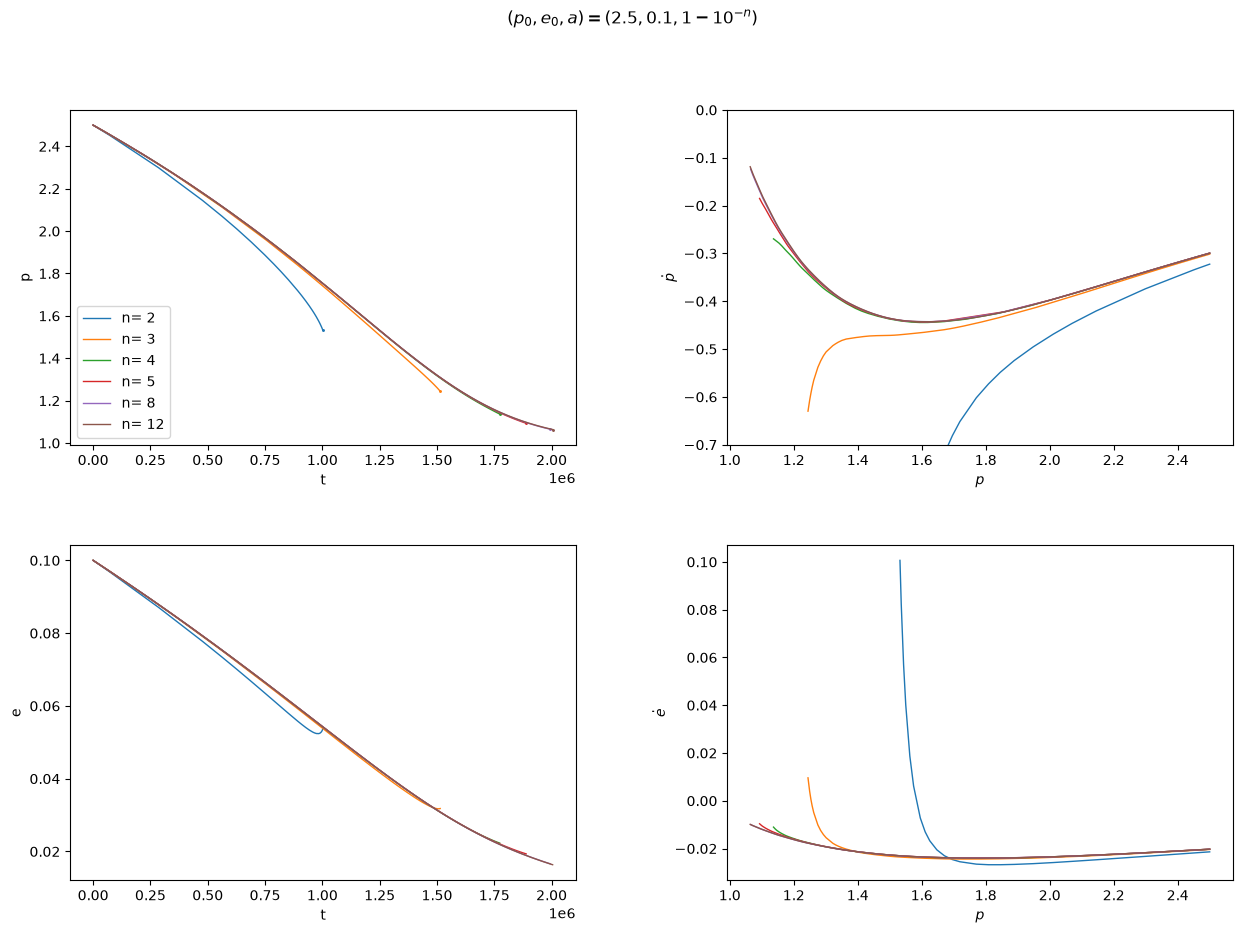

In [20]:
fig,axs = plt.subplots(2,2,figsize = (15,10))

#a = 1 - 10**(-n)
n_vals = [2,3,4,5,8,12]

for n in n_vals:
    m1 = 1e6
    m2 = 1e1
    a = 1 - 10**(-n)
    e0 = 0.1
    xI0 = 1.0  
    rhs_nex.add_fixed_parameters(m1, m2, a)
    pLSO = get_separatrix(a,e0,xI0)
    p0=2.5
    
    T = 1  #
    
    traj_pars = [m1, m2, a, p0, e0, xI0]
    
    t2, p2, e2, xI2, Phi_phi2, Phi_theta2, Phi_r2 = insp_nex(*traj_pars, T=T)

    Omega_phi, Omega_theta, Omega_r = get_fundamental_frequencies(a,p2,e2,xI2)

    pdots = []
    edots = []
    for p,e in zip(p2,e2):
        pdots.append(rhs_nex([p, e, 1])[0])
        edots.append(rhs_nex([p, e, 1])[1])
    #print(max(pdots),p2[np.argmax(pdots)])

    lws=1

    axs[0,0].plot(t2,p2,label = f"n= {round(n,3)}",lw=lws)
    axs[0,1].plot(p2,pdots,lw=lws)
    axs[1,0].plot(t2,e2,label = f"n={round(n,3)}",lw=lws)
    axs[1,1].plot(p2,edots,label = f"{round(n,3)}",lw=lws)

    axs[0,1].set_ylabel(r"$\dot{p}$")
    axs[1,1].set_ylabel(r"$\dot{e}$")
    axs[0,1].set_xlabel(r"$p$")
    axs[1,1].set_xlabel(r"$p$")


    axs[0,0].scatter(t2[-1],get_separatrix(a,e2[-1],1)+2*DELTAPMIN_REGIONC,s=1.2)



   # print(pLSO,p2[-1])

#axs[1,0].legend(loc ="upper left")
axs[0,0].set_ylabel("p")
axs[1,0].set_ylabel("e")
axs[0,0].set_xlabel("t")
axs[1,0].set_xlabel("t")
axs[0,0].legend(loc = "lower left")
axs[0,1].set_ylim(-0.7,0.0)

plt.subplots_adjust(hspace=0.3)
plt.subplots_adjust(wspace=0.3)
fig.suptitle(rf"$(p_0, e_0, a) = \left({p0}, {e0}, 1-10^{{-n}}\right)$")

#fig.savefig(f"Trajplot_e0={e0}_p0={p0}_new_grid.png", dpi=300, bbox_inches="tight")